# Practice 2.2 — Canonical Cosmetic Product Classification

**Official artifact-only presentation.** This notebook never trains, creates a Test DataLoader, or repeats Final Test. E2 was frozen before the one-time Test evaluation. All displayed results are loaded read-only from the canonical lineage.

## Phase 1 - Problem Definition

Classify cosmetic product images into 10 classes using ImageNet-pretrained ResNet18. Model selection is Validation-only; Final Test is a one-time, post-freeze estimate.

## Phase 2 - Environment Setup

This setup resolves the repository paths and loads persisted canonical artifacts. It performs no training and does not construct a Test DataLoader.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next(
    (p for p in candidates if (p / "src" / "practice_2_2").is_dir()
     and (p / "configs" / "canonical_registry.json").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Open this notebook from the canonical practice_2_2 project")

src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from practice_2_2.resources import (
    load_canonical_registry,
    resolve_dataset_root,
    resolve_final_test_dir,
    resolve_resource,
    resolve_split_manifest,
    verify_canonical_resources,
)

registry = load_canonical_registry()
assert registry.get("authority_status") == "active"
authority = verify_canonical_resources(verify_dataset_contents=False)
assert authority["test_loader_constructed"] is False
assert authority["test_evaluated"] is False

data_root = resolve_dataset_root()
split_root = resolve_split_manifest().parent
canonical_root = resolve_resource("canonical_output_dir", require_file=False)
e3_root = resolve_resource("e3_output", require_file=False)
e4_root = resolve_resource("e4_output", require_file=False)
final_root = resolve_final_test_dir()

required = [
    split_root / "split_manifest.csv", split_root / "split_summary.json",
    canonical_root / "config_snapshot.json", canonical_root / "training_histories.json",
    canonical_root / "validation_comparison.csv", canonical_root / "lineage_manifest.json",
    e3_root / "phase_2_5_report.json", e4_root / "phase_2_6_report.json",
    e3_root / "training_history_e3.json", e4_root / "training_history_e4.json",
    final_root / "final_selection.json", final_root / "final_test_summary.json",
    final_root / "final_test_metrics_by_class.csv", final_root / "final_test_confusion_matrix.csv",
    final_root / "final_test_lineage.json", final_root / "pre_test_verification.json",
    final_root / "FINAL_TEST_COMPLETED.json",
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Canonical artifacts are missing; do not regenerate Final Test. Missing:\n" + "\n".join(missing))

manifest = pd.read_csv(split_root / "split_manifest.csv")
split_summary = json.loads((split_root / "split_summary.json").read_text())
config = json.loads((canonical_root / "config_snapshot.json").read_text())
histories = json.loads((canonical_root / "training_histories.json").read_text())
lineage = json.loads((canonical_root / "lineage_manifest.json").read_text())
e3_report = json.loads((e3_root / "phase_2_5_report.json").read_text())
e4_report = json.loads((e4_root / "phase_2_6_report.json").read_text())
e3_history = json.loads((e3_root / "training_history_e3.json").read_text())
e4_history = json.loads((e4_root / "training_history_e4.json").read_text())
selection = json.loads((final_root / "final_selection.json").read_text())
final_summary = json.loads((final_root / "final_test_summary.json").read_text())
final_lineage = json.loads((final_root / "final_test_lineage.json").read_text())
pre_test_gate = json.loads((final_root / "pre_test_verification.json").read_text())
guard = json.loads((final_root / "FINAL_TEST_COMPLETED.json").read_text())
assert guard["FINAL_TEST_COMPLETED"] and guard["final_test_evaluation_count"] == 1
assert selection["test_used_for_selection"] is False
display(Markdown("**Artifact gate: PASS — active registry resolves the new canonical layout; Final Test guard remains locked.**"))

import practice_2_2.visualization_utils as vu
vu.inject_theme_css()

**Artifact gate: PASS — active registry resolves the new canonical layout; Final Test guard remains locked.**

## Phase 3 - Data Loading

### Dataset provenance

- Source: Tiki.vn API.
- Raw images: approximately 2,922.
- Final balanced files: 3,202.
- Per-image source URLs were not retained; complete raw reconstruction is a limitation.

### Cleaning pipeline

Historical processing removed corrupt/small images, exact duplicates and low-quality content, then resized to 224×224. Balancing produced 306 generated derivatives. Canonical training excludes all generated files and quarantines 2 suspicious cross-class images.

In [2]:
provenance_table = pd.DataFrame([
    ["Source", "Tiki.vn API"],
    ["Raw images", "2,922"],
    ["Final balanced files", "3,202"],
    ["Model-use originals", "2,894"],
    ["Offline-generated derivatives excluded", "306"],
    ["Cross-class suspicious images quarantined", "2"],
    ["Exact duplicate groups remaining", "0"],
    ["Per-image source URL retained", "No — documented limitation"],
], columns=["Data item", "Canonical value"])
display(vu.style_generic_table(provenance_table).hide(axis="index").set_caption("Dataset provenance and cleaning summary"))

Data item,Canonical value
Source,Tiki.vn API
Raw images,"2,922"
Final balanced files,"3,202"
Model-use originals,"2,894"
Offline-generated derivatives excluded,306
Cross-class suspicious images quarantined,2
Exact duplicate groups remaining,0
Per-image source URL retained,No — documented limitation


### Canonical duplicate-aware split

In [3]:
model_use = manifest.loc[manifest["use_for_model"]]
split_counts = model_use["split"].value_counts().reindex(["Train", "Validation", "Test"])
display(vu.render_summary_cards([
    ("Train", f"{split_counts['Train']:,}", "ACTIVE", "primary"),
    ("Validation", f"{split_counts['Validation']:,}", "ACTIVE", "primary"),
    ("Test", f"{split_counts['Test']:,}", "LOCKED", "danger"),
    ("Total", f"{split_counts.sum():,}", "ORIGINALS", "muted")
]))
display(split_counts.rename("model_use_originals").to_frame())
display(pd.DataFrame({
    "dataset_fingerprint": [split_summary["dataset_fingerprint_sha256"]],
    "split_fingerprint": [split_summary["split_fingerprint_sha256"]],
    "generated_excluded": [int(manifest["is_generated"].sum())],
    "quarantine": [int(manifest["quarantined"].sum())],
}))
assert split_counts.to_dict() == {"Train": 2016, "Validation": 438, "Test": 440}

,model_use_originals
split,
Train,2016
Validation,438
Test,440


,dataset_fingerprint,split_fingerprint,generated_excluded,quarantine
0,26dc4625f96c7cb86bc6a4df0fbed34bc8b22fb6472ef0...,52aaf97499ede5dd4689c2bb36dc0679fe04b8ec8139aa...,306,2


In [4]:
leakage_table = pd.DataFrame([
    ["Train/Validation/Test disjoint", "PASS"],
    ["Duplicate clusters do not cross splits", "PASS"],
    ["Generated families do not cross splits", "PASS"],
    ["Exact hashes do not cross splits", "PASS"],
    ["Generated derivatives used by model", "0"],
    ["Quarantined images used by model", "0"],
], columns=["Leakage control", "Status"])
display(vu.style_leakage_table(leakage_table).hide(axis="index").set_caption("Canonical leakage-safety assertions"))

Leakage control,Status
Train/Validation/Test disjoint,PASS
Duplicate clusters do not cross splits,PASS
Generated families do not cross splits,PASS
Exact hashes do not cross splits,PASS
Generated derivatives used by model,PASS
Quarantined images used by model,PASS


## Phase 4 - Exploratory Data Analysis

split,Train,Validation,Test,Total
class_name,,,,
body_wash,207,49,47,303
face_mask,202,46,49,297
facial_cleanser,230,46,45,321
lipstick,200,42,44,286
moisturizer,157,38,33,228
perfume,199,44,44,287
serum,207,45,48,300
shampoo,194,41,39,274
sunscreen,223,47,48,318


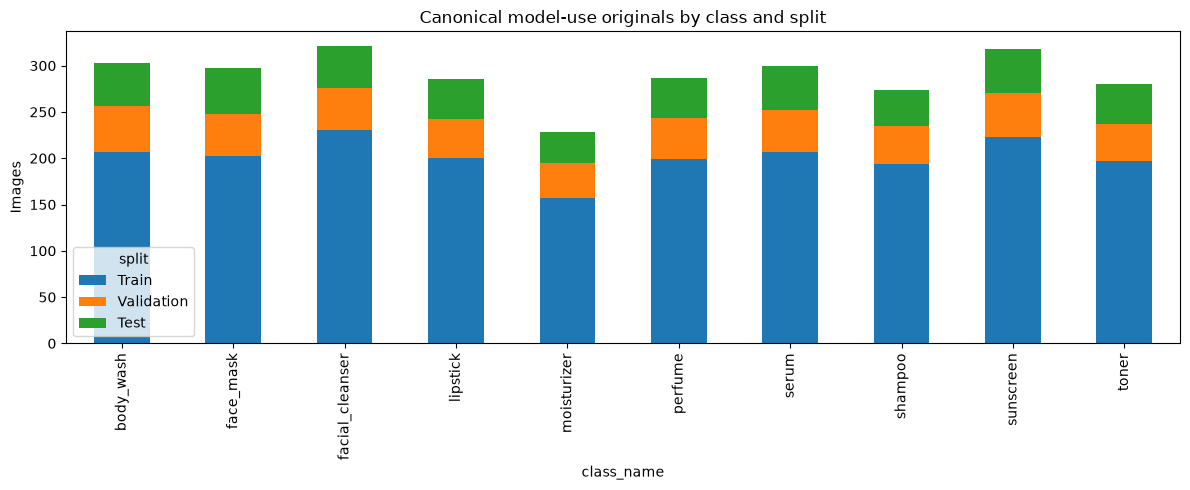

In [5]:
class_split = pd.crosstab(model_use["class_name"], model_use["split"]).reindex(columns=["Train", "Validation", "Test"])
class_split['Total'] = class_split.sum(axis=1)
display(vu.style_distribution_table(class_split))
class_split[['Train', 'Validation', 'Test']].plot(kind="bar", figsize=(12, 5), title="Canonical model-use originals by class and split", stacked=True)
plt.ylabel("Images")
plt.tight_layout()
plt.show()

### 🖼️ Dataset Examples per Class

Hiển thị 5 ảnh ngẫu nhiên cho mỗi nhãn (class) từ tập Train, tương tự cách trình bày của Practice 2.

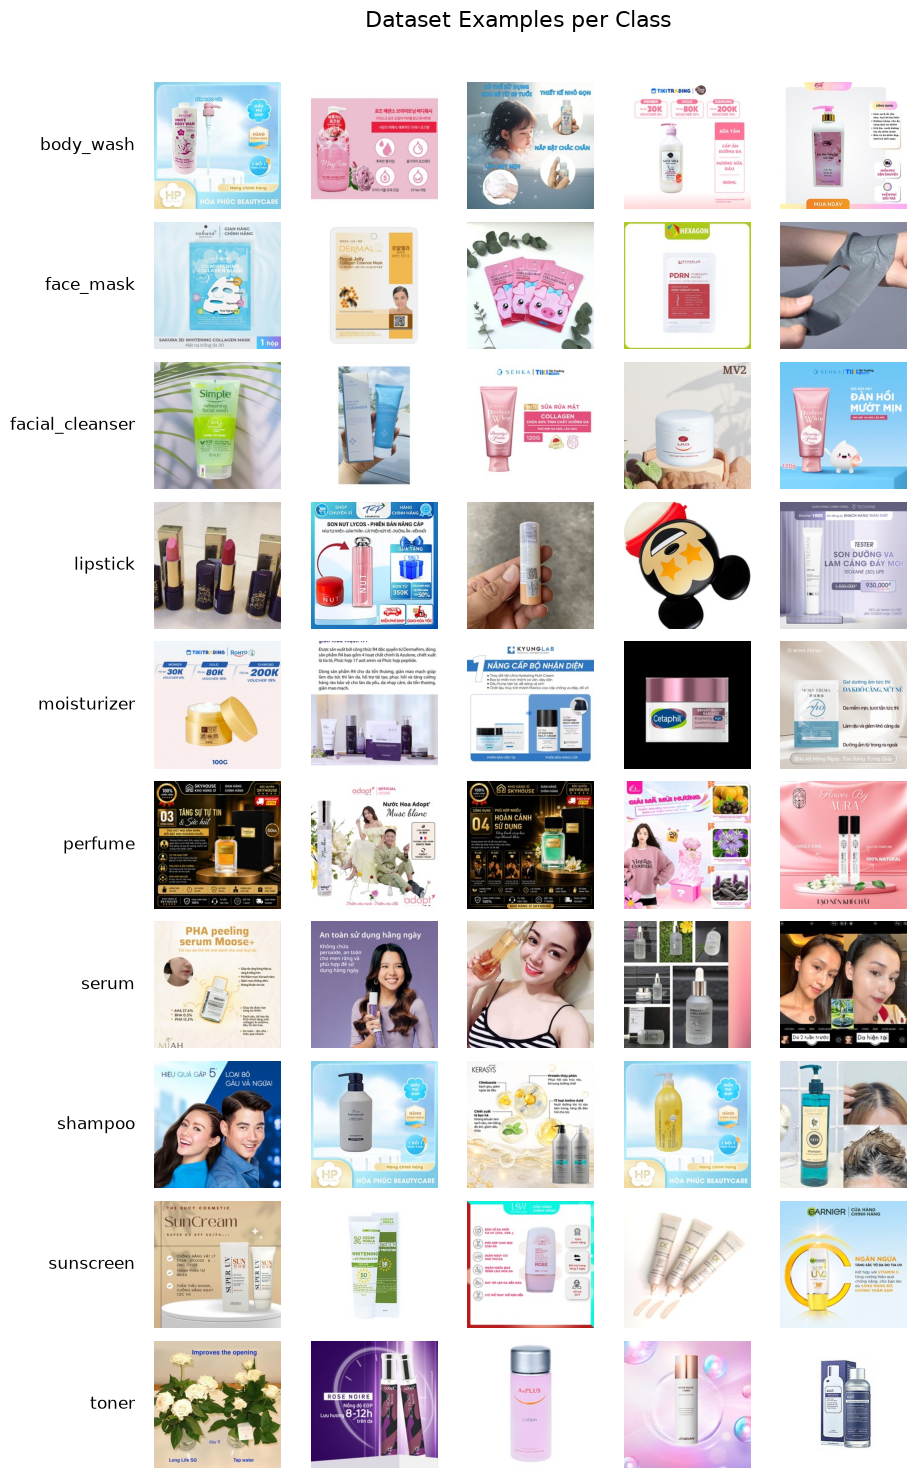

In [6]:
import matplotlib.image as mpimg

display(Markdown("### 🖼️ Dataset Examples per Class"))
display(Markdown("Hiển thị 5 ảnh ngẫu nhiên cho mỗi nhãn (class) từ tập Train, tương tự cách trình bày của Practice 2."))

classes = sorted(model_use['class_name'].unique())
n_classes = len(classes)
n_examples = 5

fig, axes = plt.subplots(n_classes, n_examples, figsize=(10, 1.8 * n_classes))

for i, cls in enumerate(classes):
    samples = model_use[(model_use['split'] == 'Train') & (model_use['class_name'] == cls)].sample(n_examples, random_state=42)
    
    for j, (idx, row) in enumerate(samples.iterrows()):
        ax = axes[i, j]
        img_path = data_root / row['relative_path']
        try:
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.axis('off')
        
        if j == 0:
            ax.text(-0.15, 0.5, cls, ha='right', va='center', transform=ax.transAxes, fontsize=12)

plt.subplots_adjust(wspace=0.05, hspace=0.1)
fig.suptitle("Dataset Examples per Class", fontsize=16, y=0.92)
plt.show()

## Phase 5 - Data Preprocessing

Only Train uses random augmentation. Validation and the one-time Test use deterministic Resize(256), CenterCrop(224), ToTensor and ImageNet normalization.

In [7]:
display(Markdown("### Canonical E2 Train transform"))
print(config["train_transform"])
display(Markdown("### Deterministic Validation transform"))
print(config["validation_transform"])

### Canonical E2 Train transform

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    RandomErasing(p=0.1, scale=(0.02, 0.1), ratio=(0.5, 2.0), value=random, inplace=False)
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


### Deterministic Validation transform

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


In [8]:
transform_audit = pd.DataFrame([
    ["RandomResizedCrop", "Train only", "scale 0.70–1.00"],
    ["HorizontalFlip", "Train only", "p=0.50"],
    ["ColorJitter", "Train only", "0.20/0.20/0.20/0.05"],
    ["RandomErasing", "Train only", "p=0.10"],
    ["Resize + CenterCrop", "Validation/Test", "deterministic 256→224"],
    ["ImageNet Normalize", "All", "mean/std from pretrained weights"],
], columns=["Transform", "Applied to", "Configuration"])
display(vu.style_transform_table(transform_audit).hide(axis="index").set_caption("Preprocessing isolation"))

Transform,Applied to,Configuration
RandomResizedCrop,TRAIN ONLY,scale 0.70–1.00
HorizontalFlip,TRAIN ONLY,p=0.50
ColorJitter,TRAIN ONLY,0.20/0.20/0.20/0.05
RandomErasing,TRAIN ONLY,p=0.10
Resize + CenterCrop,VAL / TEST,deterministic 256→224
ImageNet Normalize,ALL SPLITS,mean/std from pretrained weights


## Phase 6 - Model Building and Baseline

ResNet18 uses ImageNet pretrained initialization. E2 trains the full `layer4` and dropout-regularized classifier head: 8,398,858 trainable parameters out of 11,181,642.

In [9]:
model_table = pd.DataFrame([
    ["Backbone", "ResNet18"],
    ["Initialization", "ImageNet ResNet18_Weights.DEFAULT"],
    ["Classifier", "Dropout(0.20) + Linear(512, 10)"],
    ["E1 trainable", "Classifier only — 5,130 params"],
    ["E2 trainable", "Full layer4 + classifier — 8,398,858 params"],
    ["Total parameters", "11,181,642"],
    ["Frozen BatchNorm", "eval mode; running statistics locked"],
], columns=["Architecture item", "Canonical configuration"])
display(vu.style_generic_table(model_table).hide(axis="index").set_caption("Model architecture and fine-tuning depth"))

Architecture item,Canonical configuration
Backbone,ResNet18
Initialization,ImageNet ResNet18_Weights.DEFAULT
Classifier,"Dropout(0.20) + Linear(512, 10)"
E1 trainable,"Classifier only — 5,130 params"
E2 trainable,"Full layer4 + classifier — 8,398,858 params"
Total parameters,"11,181,642"
Frozen BatchNorm,eval mode; running statistics locked


### E1 — head-only baseline

E1 reached 59.87% Train and 59.82% Validation Accuracy. The near-zero gap reflects underfitting, not superior generalization.

## Phase 7 - Model Training

### E2 — full layer4 + head

E2 reached 98.31% Train Accuracy, 78.31% Validation Accuracy and 0.7821 Validation Macro F1. It had the strongest Validation performance and was selected.

In [10]:
training_config = pd.DataFrame([
    ["Seed", 42], ["Batch size", 32], ["Maximum epochs", 15],
    ["Optimizer", "AdamW"], ["Head LR", 0.001], ["Backbone LR", 0.0001],
    ["Weight decay", 0.0002], ["Scheduler", "ReduceLROnPlateau"],
    ["Early stopping", "val_loss, patience=3"],
    ["Best checkpoint", "Validation Accuracy"],
    ["Loss", "Class-weighted CrossEntropy + label smoothing 0.05"],
    ["Gradient clipping", 1.0],
], columns=["Training item", "Value"])
display(vu.style_generic_table(training_config).hide(axis="index").set_caption("Canonical controlled training configuration"))

Training item,Value
Seed,42
Batch size,32
Maximum epochs,15
Optimizer,AdamW
Head LR,0.001000
Backbone LR,0.000100
Weight decay,0.000200
Scheduler,ReduceLROnPlateau
Early stopping,"val_loss, patience=3"
Best checkpoint,Validation Accuracy


### Training dynamics and overfitting analysis

epoch,train_loss,train_acc,val_loss,val_acc,val_macro_f1,generalization_gap,lr
1,1.9967,39.34%,1.4222,58.45%,0.574911,-19.112171,1.0e-03
2,1.1420,66.96%,1.2508,67.12%,0.661395,-0.159002,1.0e-03
3,0.8863,79.17%,1.2363,70.55%,0.703837,8.618721,1.0e-03
4,0.7166,85.37%,1.2636,68.26%,0.686213,17.102223,1.0e-03
5,0.6330,89.43%,1.1717,71.46%,0.711908,17.973337,1.0e-03
6,0.5640,91.91%,1.1766,73.29%,0.734185,18.627011,1.0e-03
7,0.5279,93.70%,1.1518,72.83%,0.728483,20.869347,1.0e-03
8,0.4939,95.54%,1.2306,72.37%,0.723716,23.161285,1.0e-03
9,0.4821,96.23%,1.1445,73.74%,0.739239,22.485866,1.0e-03
10,0.4600,96.83%,1.1372,75.11%,0.749112,21.711242,1.0e-03


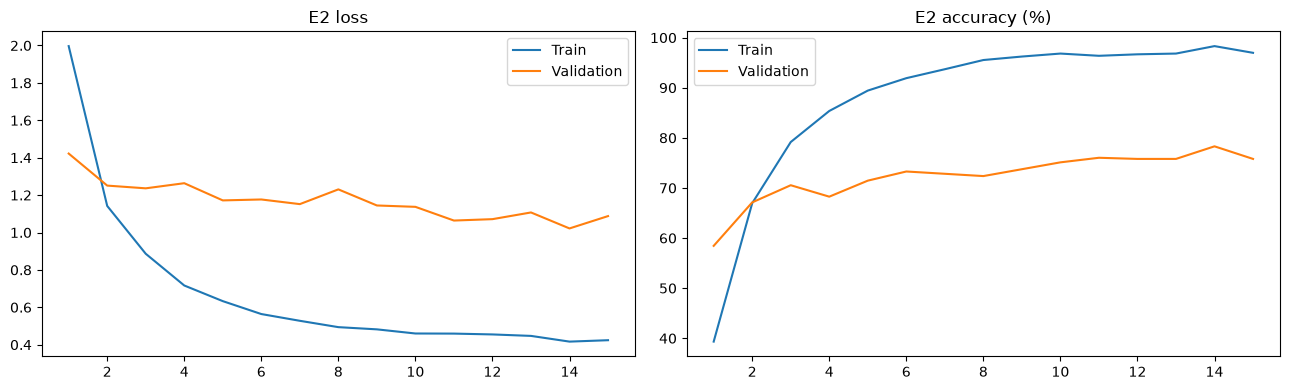

In [11]:
e2_history = pd.DataFrame(histories["E2_partial_finetune"])
display(vu.style_training_history(e2_history[["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "val_macro_f1", "generalization_gap", "lr"]]))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(e2_history["epoch"], e2_history["train_loss"], label="Train")
axes[0].plot(e2_history["epoch"], e2_history["val_loss"], label="Validation")
axes[0].set_title("E2 loss"); axes[0].legend()
axes[1].plot(e2_history["epoch"], e2_history["train_acc"], label="Train")
axes[1].plot(e2_history["epoch"], e2_history["val_acc"], label="Validation")
axes[1].set_title("E2 accuracy (%)"); axes[1].legend()
plt.tight_layout(); plt.show()

## Phase 8 - Controlled Experiments

### E3 — reduced-capacity ablation

E3 trained only `layer4.1 + head`. Validation Accuracy fell to 70.32%, showing insufficient domain adaptation. It was rejected before Test.

### E4 — augmentation ablation

E4 returned to full layer4 and used stronger online augmentation. Gap fell to 13.39 points, but Validation Accuracy fell to 72.37%. It was rejected before Test.

### Validation-only experiment comparison

Experiment,Architecture,Train Acc (%),Val Acc (%),Val Loss,Val F1,Gap (%),Status
E1,Head only,59.87%,59.82%,1.3976,0.5975,0.05 pp,UNDERFIT
E2,Layer4 + Head,98.31%,78.31%,0.7712,0.7844,20.00 pp,OVERFIT
E3,Layer4.1 + Head,90.08%,70.32%,1.2799,0.7017,19.76 pp,OVERFIT (REDUCED)
E4,Layer4 + Head (Aug+),85.76%,72.37%,1.2491,0.7229,13.39 pp,OVERFIT (REDUCED)


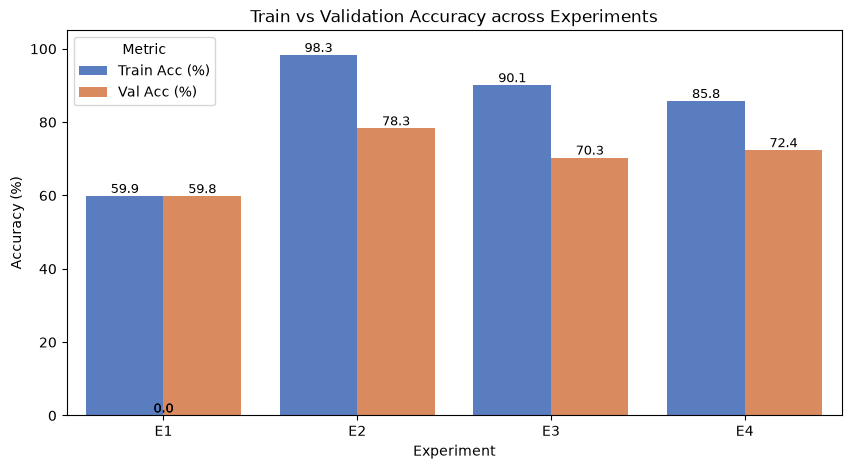

In [12]:
comparison = pd.DataFrame([
    ["E1", "Head only", 59.87, 59.82, 1.3976, 0.5975, 0.05, "Underfit"],
    ["E2", "Layer4 + Head", 98.31, 78.31, 0.7712, 0.7844, 20.00, "Overfit"],
    ["E3", "Layer4.1 + Head", e3_report["e3"]["train_accuracy"], e3_report["e3"]["validation_accuracy"], e3_report["e3"]["validation_loss"], e3_report["e3"]["validation_macro_f1"], e3_report["e3"]["generalization_gap"], "Overfit (Reduced)"],
    ["E4", "Layer4 + Head (Aug+)", e4_report["e4"]["train_accuracy"], e4_report["e4"]["validation_accuracy"], e4_report["e4"]["validation_loss"], e4_report["e4"]["validation_macro_f1"], e4_report["e4"]["generalization_gap"], "Overfit (Reduced)"],
], columns=["Experiment", "Architecture", "Train Acc (%)", "Val Acc (%)", "Val Loss", "Val F1", "Gap (%)", "Status"])
display(vu.style_model_comparison(comparison).hide(axis="index"))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
melted_comp = comparison.melt(id_vars=['Experiment'], value_vars=['Train Acc (%)', 'Val Acc (%)'], var_name='Metric', value_name='Accuracy')
sns.barplot(data=melted_comp, x='Experiment', y='Accuracy', hue='Metric', palette='muted')
plt.title('Train vs Validation Accuracy across Experiments')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9)
plt.show()

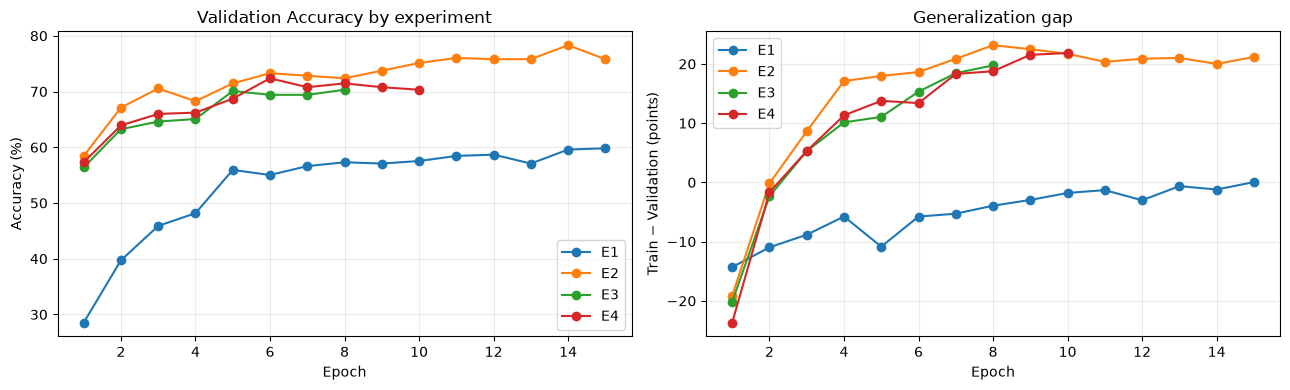

**Evidence:** E2 has the highest Validation peak; E3 loses domain adaptation and E4 lowers memorization but also lowers Validation performance.

In [13]:
all_histories = {
    "E1": pd.DataFrame(histories["E1_head_only"]),
    "E2": pd.DataFrame(histories["E2_partial_finetune"]),
    "E3": pd.DataFrame(e3_history),
    "E4": pd.DataFrame(e4_history),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, history in all_histories.items():
    axes[0].plot(history["epoch"], history["val_acc"], marker="o", label=name)
    axes[1].plot(history["epoch"], history["generalization_gap"], marker="o", label=name)
axes[0].set(title="Validation Accuracy by experiment", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].set(title="Generalization gap", xlabel="Epoch", ylabel="Train − Validation (points)")
for ax in axes: ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()
display(Markdown("**Evidence:** E2 has the highest Validation peak; E3 loses domain adaptation and E4 lowers memorization but also lowers Validation performance."))

## Phase 9 - Model Selection and Checkpoint Verification

### Freeze canonical winner

E2 was frozen before Test using Validation Accuracy as the selection metric. E3/E4 decisions could not be revisited after Test.

In [14]:
display(vu.render_summary_cards([
    ("Selected", selection["selected_experiment_id"], "WINNER", "success"),
    ("Val Accuracy", f'{selection["validation_accuracy"]*100:.2f}%' if selection["validation_accuracy"] < 1 else f'{selection["validation_accuracy"]:.2f}%', "BEST", "success"),
    ("Gap", f'{selection.get("generalization_gap", 20):.2f}%', "OVERFIT", "danger")
]))
display(pd.Series(selection, name="frozen_selection").to_frame())

,frozen_selection
immutable,True
canonical_run_id,canonical_26dc4625_52aaf974_s42_v1
selected_experiment_id,E2_partial_finetune
selection_metric,validation_accuracy
tie_breaker,validation_loss
best_epoch,14
validation_accuracy,78.310502
validation_macro_f1,0.782096
checkpoint_path,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...
checkpoint_sha256,4f65bec200d023c51f95493833d057029b83a92729c3b8...


### 📈 Training Curves: Validation Accuracy & Loss

Biểu đồ so sánh quá trình huấn luyện (Learning Curves) giữa các thử nghiệm E1 và E2.

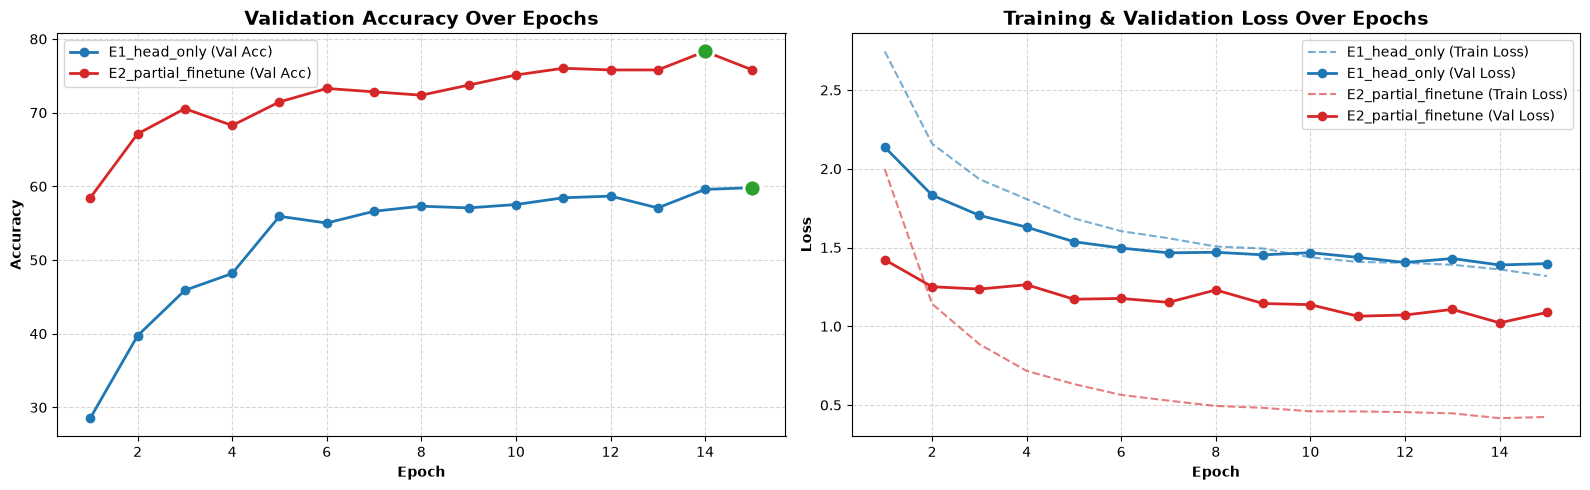

In [15]:
display(Markdown("### 📈 Training Curves: Validation Accuracy & Loss"))
display(Markdown("Biểu đồ so sánh quá trình huấn luyện (Learning Curves) giữa các thử nghiệm E1 và E2."))

histories_path = final_root.parent / "training_histories.json"
if histories_path.exists():
    import json
    with open(histories_path, 'r') as f:
        histories = json.load(f)
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    colors = {'E1_head_only': '#1f77b4', 'E2_partial_finetune': '#d62728'}
    
    for exp_id, hist in histories.items():
        epochs = hist['epoch']
        color = colors.get(exp_id, 'gray')
        
        # Validation Accuracy
        ax1.plot(epochs, hist['val_acc'], label=f"{exp_id} (Val Acc)", color=color, linewidth=2, marker='o')
        
        # Training and Validation Loss
        ax2.plot(epochs, hist['train_loss'], label=f"{exp_id} (Train Loss)", color=color, linestyle='--', alpha=0.6)
        ax2.plot(epochs, hist['val_loss'], label=f"{exp_id} (Val Loss)", color=color, linewidth=2, marker='o')
        
        # Highlight best epoch
        best_ep = hist.get('best_epoch')
        if best_ep and best_ep in epochs:
            best_idx = epochs.index(best_ep)
            ax1.scatter([best_ep], [hist['val_acc'][best_idx]], s=150, color='#2ca02c', zorder=5, edgecolors='white', linewidths=2)
            
    ax1.set_title("Validation Accuracy Over Epochs", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Epoch", fontweight='bold')
    ax1.set_ylabel("Accuracy", fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()
    
    ax2.set_title("Training & Validation Loss Over Epochs", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Epoch", fontweight='bold')
    ax2.set_ylabel("Loss", fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("*Không tìm thấy file training_histories.json*"))

In [16]:
checkpoint_table = pd.DataFrame([
    ["Selected experiment", selection["selected_experiment_id"]],
    ["Best epoch", selection["best_epoch"]],
    ["Selection metric", selection["selection_metric"]],
    ["Validation Accuracy", f'{selection["validation_accuracy"]:.4f}%'],
    ["Validation Macro F1", f'{selection["validation_macro_f1"]:.4f}'],
    ["Checkpoint SHA-256", selection["checkpoint_sha256"]],
    ["Config SHA-256", selection["config_fingerprint_sha256"]],
    ["Pre-Test verification gate", pre_test_gate["status"]],
    ["Test used for selection", selection["test_used_for_selection"]],
], columns=["Verification item", "Value"])
display(vu.style_generic_table(checkpoint_table).hide(axis="index").set_caption("Frozen winner and checkpoint identity"))

Verification item,Value
Selected experiment,E2_partial_finetune
Best epoch,14
Selection metric,validation_accuracy
Validation Accuracy,78.3105%
Validation Macro F1,0.7821
Checkpoint SHA-256,4f65bec200d023c51f95493833d057029b83a92729c3b88dd9159158dd949ae3
Config SHA-256,25a4bc76ad5f58152e5a0af3e4fa79566f2191545a060c50fef9a4f9627c6c8d
Pre-Test verification gate,PASS
Test used for selection,False


## Phase 10 - Final Test Evaluation

Final Test ran exactly once. No retraining or model reselection occurred afterward.

In [17]:
final_table = pd.DataFrame([
    ["Test Loss", final_summary["test_loss"]],
    ["Test Accuracy (%)", final_summary["test_accuracy"]],
    ["Macro Precision", final_summary["macro_precision"]],
    ["Macro Recall", final_summary["macro_recall"]],
    ["Macro F1", final_summary["macro_f1"]],
    ["Weighted F1", final_summary["weighted_f1"]],
    ["Correct", final_summary["correct_predictions"]],
    ["Incorrect", final_summary["incorrect_predictions"]],
    ["Samples", final_summary["total_predictions"]],
], columns=["Metric", "Result"])
display(vu.style_test_metrics_table(final_table).hide(axis="index"))
display(Markdown(f"Validation Accuracy 78.31% vs Test Accuracy {final_summary['test_accuracy']:.2f}%: difference **{78.31050228310502-final_summary['test_accuracy']:.2f} percentage points**."))

Metric,Result
Test Loss,1.0187
Test Accuracy (%),76.36%
Macro Precision,0.7654
Macro Recall,0.7655
Macro F1,0.7617
Weighted F1,0.7622
Correct,336
Incorrect,104
Samples,440


Validation Accuracy 78.31% vs Test Accuracy 76.36%: difference **1.95 percentage points**.

## Phase 11 - Error Analysis and Visualization

### Per-class metrics and confusion matrix

,class_name,precision,recall,f1,support
0,body_wash,0.794872,0.659574,0.720930,47
1,face_mask,0.854167,0.836735,0.845361,49
2,facial_cleanser,0.882353,0.666667,0.759494,45
3,lipstick,0.769231,0.909091,0.833333,44
4,moisturizer,0.694444,0.757576,0.724638,33
5,perfume,0.851064,0.909091,0.879121,44
6,serum,0.714286,0.625000,0.666667,48
7,shampoo,0.681818,0.769231,0.722892,39
8,sunscreen,0.666667,0.708333,0.686869,48
9,toner,0.744681,0.813953,0.777778,43


,body_wash,face_mask,facial_cleanser,lipstick,moisturizer,perfume,serum,shampoo,sunscreen,toner
true_class,,,,,,,,,,
body_wash,31,2,0,1,0,0,1,10,2,0
face_mask,0,41,0,0,0,1,1,1,2,3
facial_cleanser,3,2,30,2,3,1,2,0,2,0
lipstick,1,0,0,40,0,2,1,0,0,0
moisturizer,1,0,2,1,25,0,2,0,1,1
perfume,1,0,0,0,0,40,0,0,0,3
serum,1,1,1,1,4,0,30,0,5,5
shampoo,1,0,0,3,2,1,0,30,2,0
sunscreen,0,2,1,1,1,1,5,3,34,0


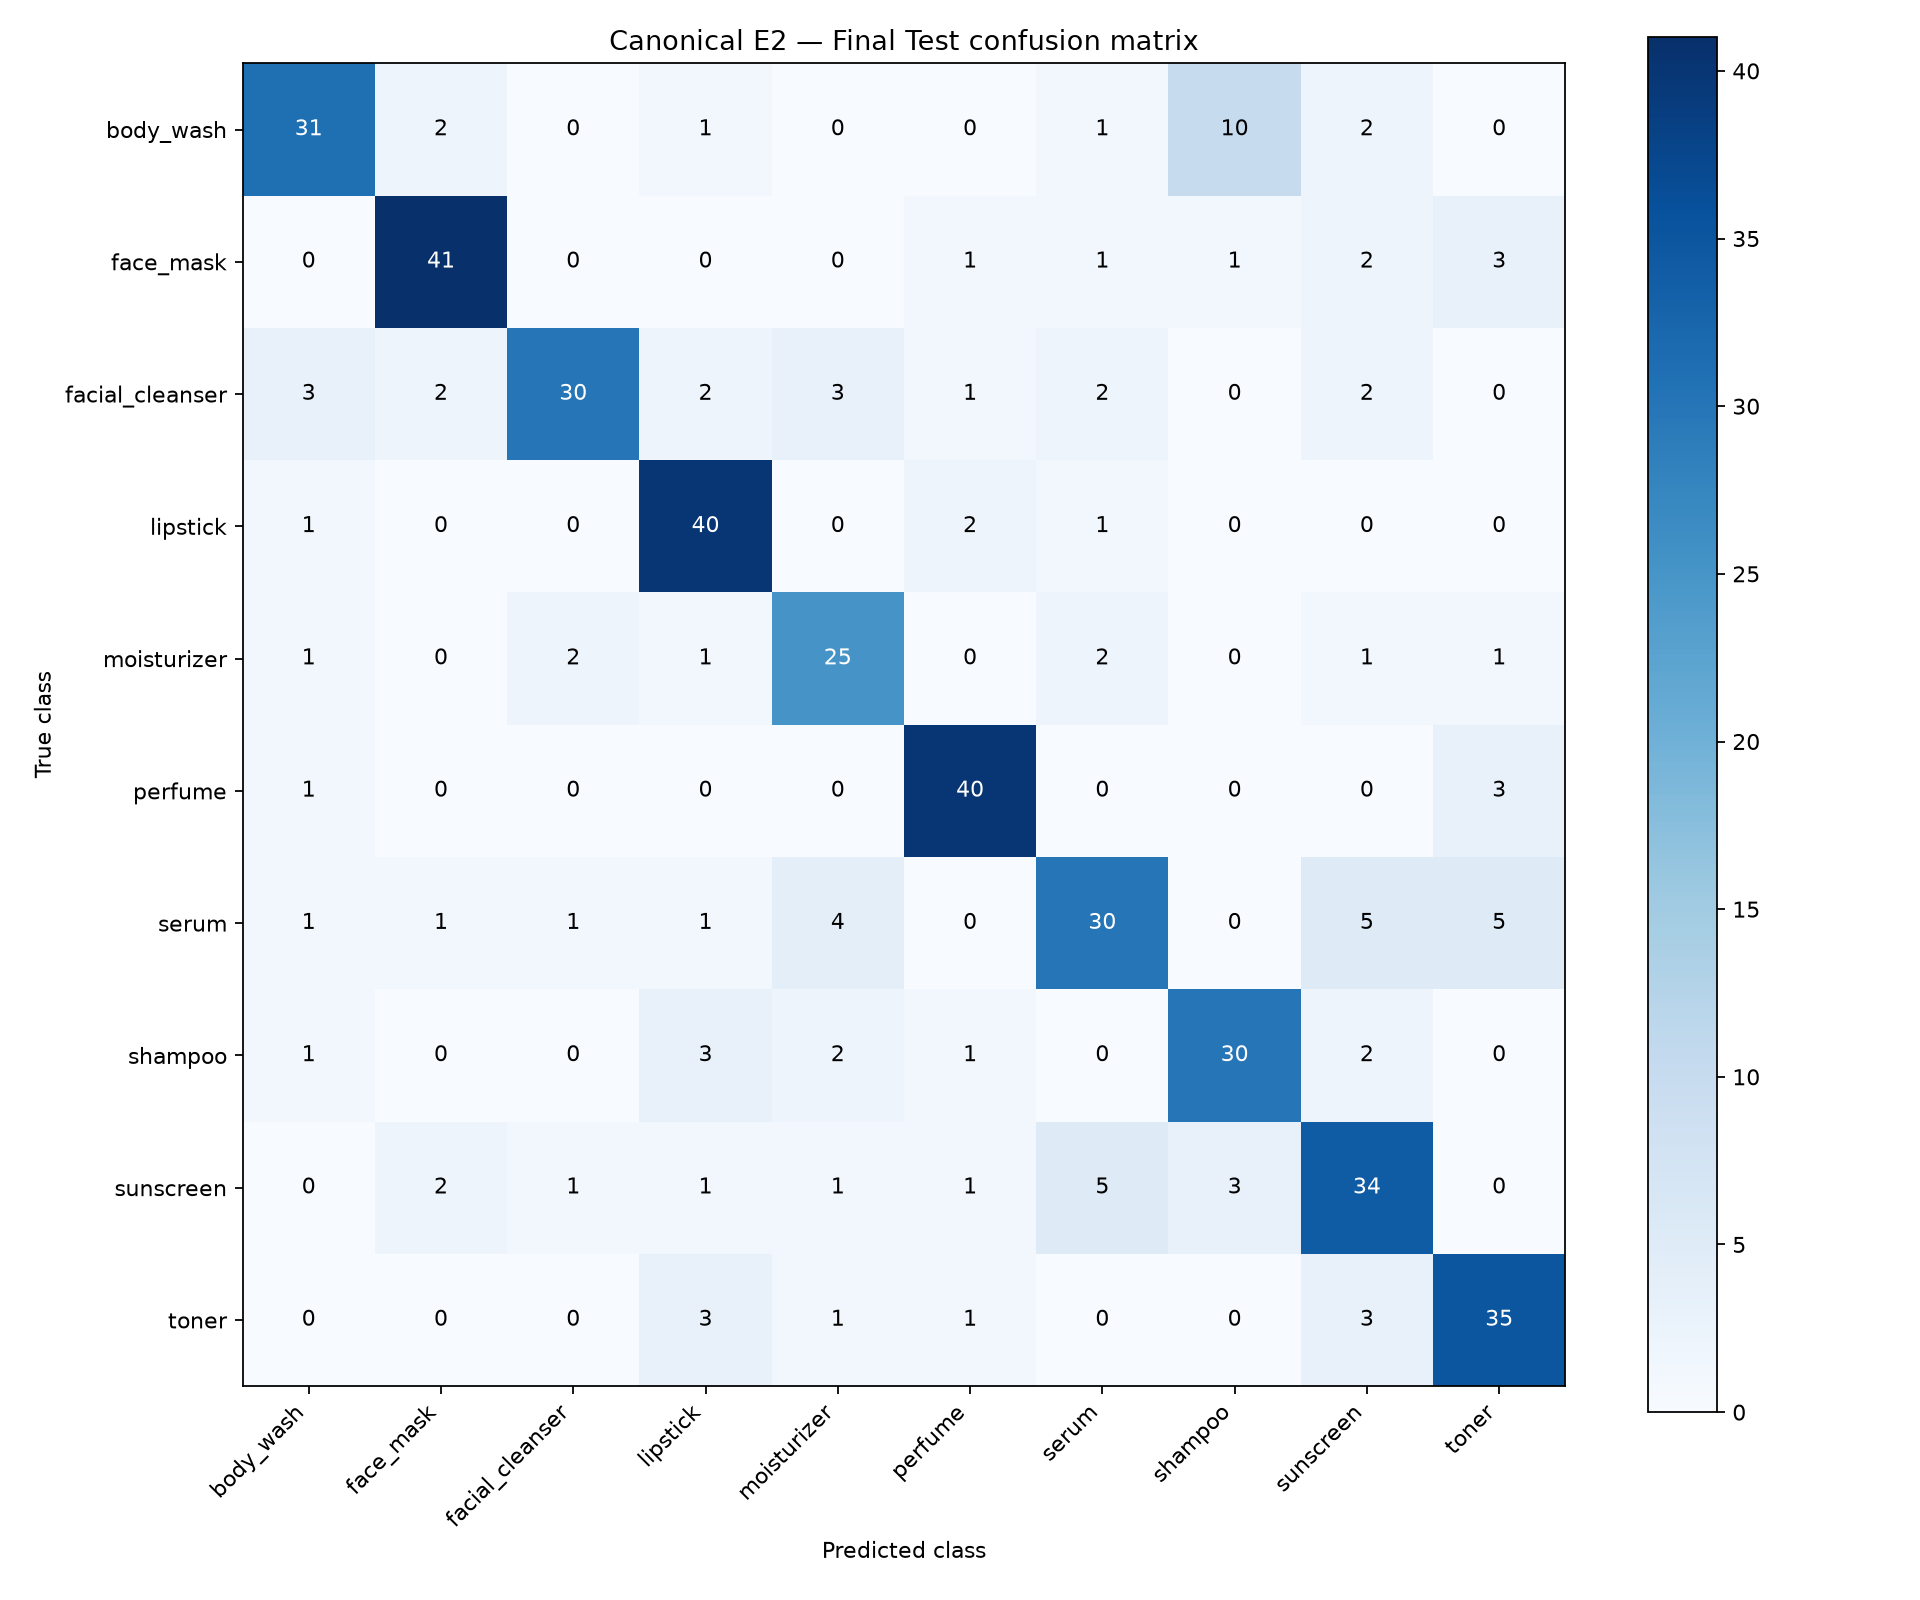

In [18]:
per_class = pd.read_csv(final_root / "final_test_metrics_by_class.csv")
confusion = pd.read_csv(final_root / "final_test_confusion_matrix.csv", index_col=0)
display(per_class)
display(confusion)
display(Image(filename=str(final_root / "final_test_confusion_matrix.png")))

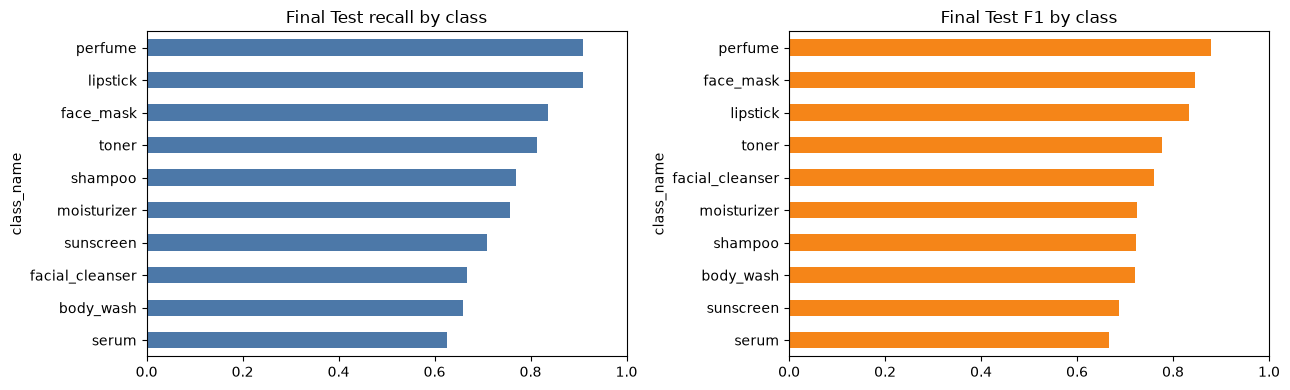

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
per_class.sort_values("recall").plot.barh(x="class_name", y="recall", ax=axes[0], legend=False, color="#4C78A8")
per_class.sort_values("f1").plot.barh(x="class_name", y="f1", ax=axes[1], legend=False, color="#F58518")
axes[0].set(title="Final Test recall by class", xlim=(0, 1))
axes[1].set(title="Final Test F1 by class", xlim=(0, 1))
plt.tight_layout(); plt.show()

### Confusion pairs and high-confidence errors

Error analysis is reporting-only and was not used for retraining or tuning.

### Five lowest-recall classes

,class_name,recall
0,serum,0.625000
1,body_wash,0.659574
2,facial_cleanser,0.666667
3,sunscreen,0.708333
4,moisturizer,0.757576


### Top confusion pairs (Actual -> Predicted)

,true_class,predicted_class,count
0,body_wash,shampoo,10
1,serum,sunscreen,5
2,serum,toner,5
3,sunscreen,serum,5
4,serum,moisturizer,4
5,face_mask,toner,3
6,facial_cleanser,body_wash,3
7,facial_cleanser,moisturizer,3
8,perfume,toner,3
9,shampoo,lipstick,3


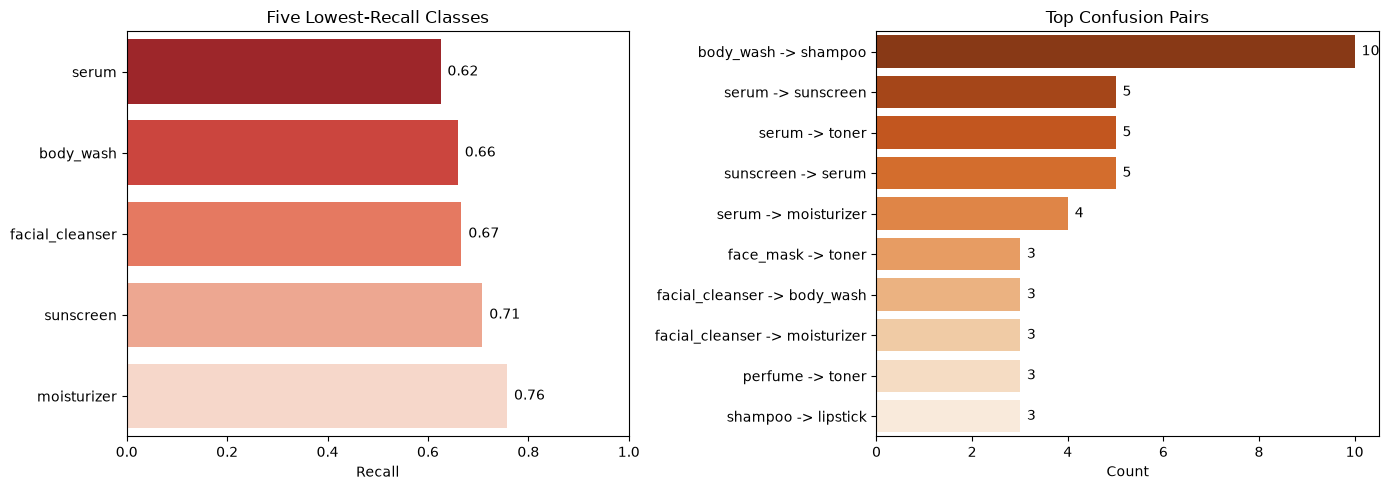

In [20]:
display(Markdown("### Five lowest-recall classes"))
lowest_recall_df = pd.DataFrame(final_summary["five_lowest_recall_classes"])
display(lowest_recall_df)

display(Markdown("### Top confusion pairs (Actual -> Predicted)"))
top_confusion_df = pd.DataFrame(final_summary["top_confusion_pairs"])
display(top_confusion_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot lowest recall classes
import seaborn as sns
sns.barplot(data=lowest_recall_df, x='recall', y='class_name', ax=axes[0], hue='class_name', legend=False, palette='Reds_r')
axes[0].set_title('Five Lowest-Recall Classes')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')

# Plot top confusion pairs
top_confusion_df['pair'] = top_confusion_df['true_class'] + ' -> ' + top_confusion_df['predicted_class']
sns.barplot(data=top_confusion_df, x='count', y='pair', ax=axes[1], hue='pair', legend=False, palette='Oranges_r')
axes[1].set_title('Top Confusion Pairs')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

## Phase 12 - Save/Load Verification, Limitations and Conclusion

### Reproducibility and save/load verification

- Canonical E2 checkpoint identity is linked by SHA-256.
- Final selection was frozen before Test.
- Model state did not change during inference.
- Final Test completion guard prevents repeated evaluation.

### Limitations

- Per-image Tiki URLs/product IDs were not persisted.
- Raw reconstruction and historical offline balancing are not fully reproducible.
- Visually overlapping packaging and some weakly informative images remain.
- Results use one canonical split and seed rather than cross-validation.
- This learning project is not production-ready.

In [21]:
artifact_hashes = pd.DataFrame(
    list(final_lineage["output_artifact_sha256"].items()),
    columns=["Artifact", "SHA-256"],
)
display(artifact_hashes)
final_audit = pd.DataFrame([
    ["Dataset provenance", "PARTIAL", "Per-image URLs unavailable"],
    ["Cleaning pipeline", "PARTIAL", "Historical balance scripts unavailable"],
    ["Leakage protection", "PASS", "Canonical duplicate-aware split"],
    ["Training pipeline", "PASS", "Frozen config and histories"],
    ["Validation-only selection", "PASS", "E2 frozen before Test"],
    ["Final Test integrity", "PASS", "Exactly one evaluation; guard locked"],
    ["Artifact lineage", "PASS", "Hashes and canonical paths linked"],
    ["Notebook presentation", "PASS", "Artifact-only Run All"],
], columns=["Area", "Status", "Evidence"])
display(vu.style_leakage_table(final_audit).hide(axis="index").set_caption("Final submission audit"))

,Artifact,SHA-256
0,final_selection.json,f532909243ba3f06f7860ca77e76a89718b5cee6fab765...
1,pre_test_verification.json,499e9ed74c26a247ab2851cc40575b74f5346178a2036a...
2,final_test_summary.json,b346f542d600c8442571f597ce71093a9d1230a1d7fe2c...
3,final_test_metrics_by_class.csv,75ae705579eef5858b03bc4f8e12640c83b6acde65a1c0...
4,final_test_predictions.csv,d8d18155858483b7f3bb171aa5813a5c0c79f918b1bc50...
5,final_test_confusion_matrix.csv,42b53dd3b67774502616b8481251610db79aef17fe6443...
6,final_test_confusion_matrix.png,8e33738cd5135672d7ffd787302f6b0668f391ef31be9c...
7,misclassified_samples.csv,32872d88662582328c3bf6a4b20d9bc081dd2544d33a59...
8,selected_checkpoint,4f65bec200d023c51f95493833d057029b83a92729c3b8...
9,config_snapshot,44c8ad38c836d3cf4590f7afa9a62b244265f027209a9a...


Area,Status,Evidence
Dataset provenance,PARTIAL,Per-image URLs unavailable
Cleaning pipeline,PARTIAL,Historical balance scripts unavailable
Leakage protection,PASS,Canonical duplicate-aware split
Training pipeline,PASS,Frozen config and histories
Validation-only selection,PASS,E2 frozen before Test
Final Test integrity,PASS,Exactly one evaluation; guard locked
Artifact lineage,PASS,Hashes and canonical paths linked
Notebook presentation,PASS,Artifact-only Run All


### Conclusion

E2 was the best Validation-only experiment and achieved **76.36% Final Test Accuracy** and **0.7617 Macro F1** on 440 samples. Leakage controls, checkpoint identity, artifact hashes and the one-time Test guard passed. The project is internally consistent, with provenance/reconstruction limitations disclosed.

### 🔍 Highest-confidence predictions

Hiển thị trực quan các dự đoán đúng và sai có độ tự tin cao nhất của mô hình, giống với bố cục của Practice 2.

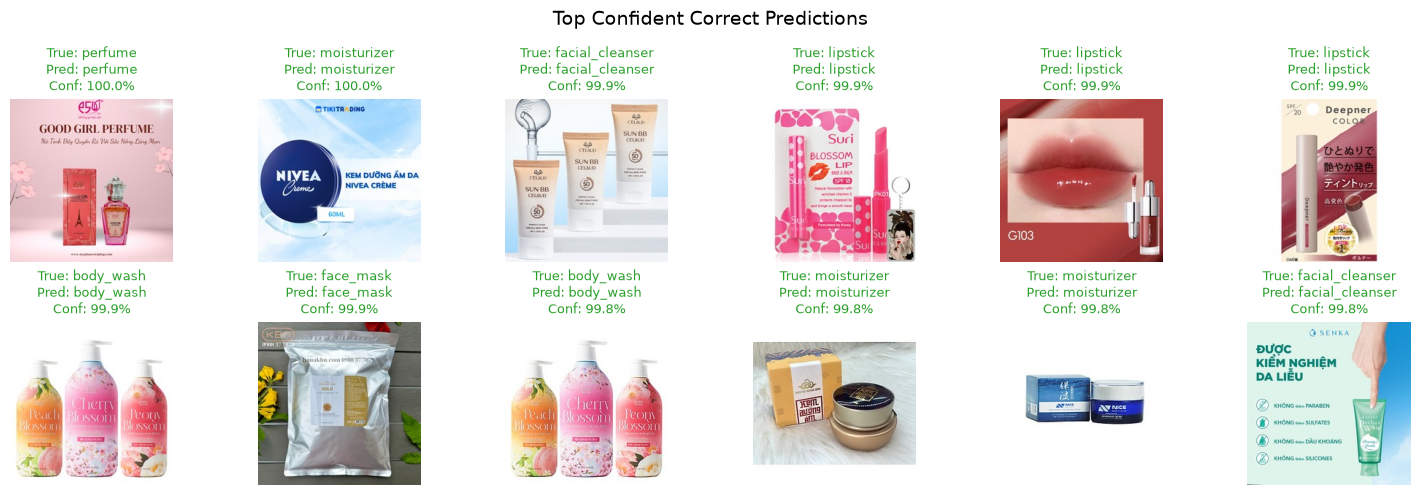

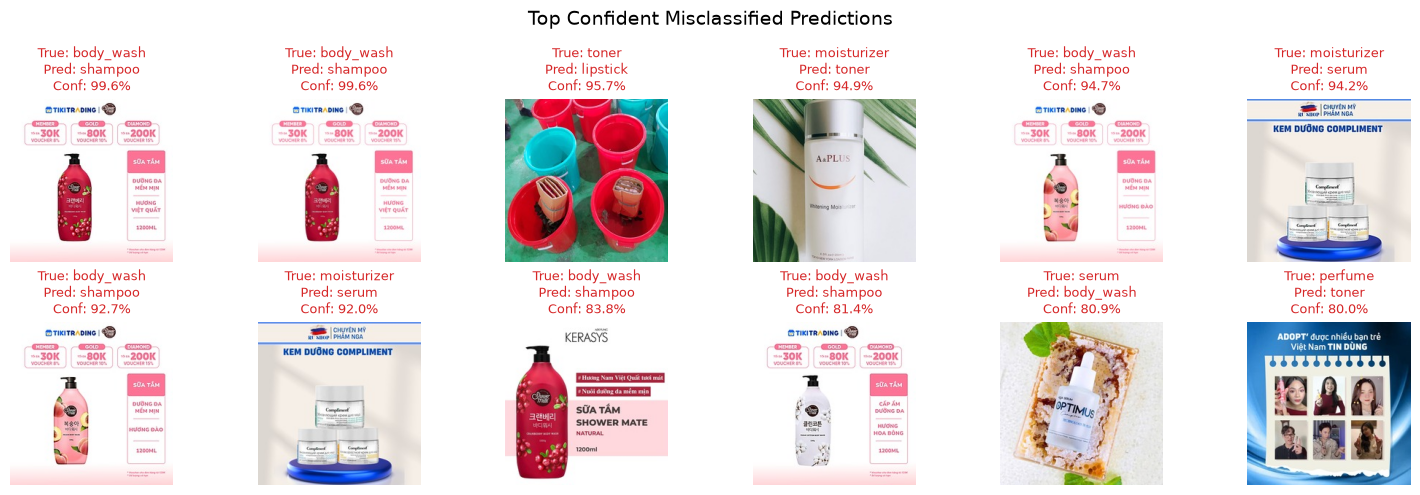

In [22]:
display(Markdown("### 🔍 Highest-confidence predictions"))
display(Markdown("Hiển thị trực quan các dự đoán đúng và sai có độ tự tin cao nhất của mô hình, giống với bố cục của Practice 2."))

predictions_path = final_root / "final_test_predictions.csv"
if predictions_path.exists():
    preds = pd.read_csv(predictions_path)
    
    # 1. Highest-confidence correct predictions
    # Filter where correct is True (string 'True' or bool True)
    correct_mask = preds['correct'] == True
    if correct_mask.dtype != bool:
        correct_mask = preds['correct'].astype(str).str.lower() == 'true'
        
    correct_preds = preds[correct_mask].nlargest(12, 'confidence')
    
    fig, axes = plt.subplots(2, 6, figsize=(15, 5))
    fig.suptitle("Top Confident Correct Predictions", fontsize=14)
    
    for ax, (_, row) in zip(axes.flatten(), correct_preds.iterrows()):
        img_path = data_root / row['relative_path']
        try:
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
        except Exception:
            pass
        ax.axis('off')
        ax.set_title(f"True: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']*100:.1f}%", 
                     color='#2ca02c', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    # 2. Highest-confidence incorrect predictions
    incorrect_mask = ~correct_mask
    incorrect_preds = preds[incorrect_mask].nlargest(12, 'confidence')
    
    fig, axes = plt.subplots(2, 6, figsize=(15, 5))
    fig.suptitle("Top Confident Misclassified Predictions", fontsize=14)
    
    for ax, (_, row) in zip(axes.flatten(), incorrect_preds.iterrows()):
        img_path = data_root / row['relative_path']
        try:
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
        except Exception:
            pass
        ax.axis('off')
        ax.set_title(f"True: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']*100:.1f}%", 
                     color='#d62728', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("*Không tìm thấy file final_test_predictions.csv*"))